#1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#2.Load the Dataset

In [2]:
df = pd.read_csv(r'/content/drive/MyDrive/Mental_Health_Score/Student Social Media And Mental Health Impact.csv')

In [3]:
# Looking for number of rows and columns
df.shape

(5000, 13)

In [4]:
# Print the first five rows
df.head()


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.tail()# to look at last five rows

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7
4999,19,Male,China,Undergraduate,WeChat,Entertainment,5.4,177,1.2,1.5,6.3,High,6.1


In [6]:
df.isnull().sum() # used to check whether there is null values.

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [7]:
df.duplicated().sum()# to check whether there is any duplicates in dataset

np.int64(2)

In [8]:
df.describe()# will give me the statistics of the dataset

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


#3.Exploratory Data Analysis (EDA)

##3.1 - Distribution of The target (Mental_Health_Score)



*   Before predicting anything, we need to understand the shape of what we are predicting



<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

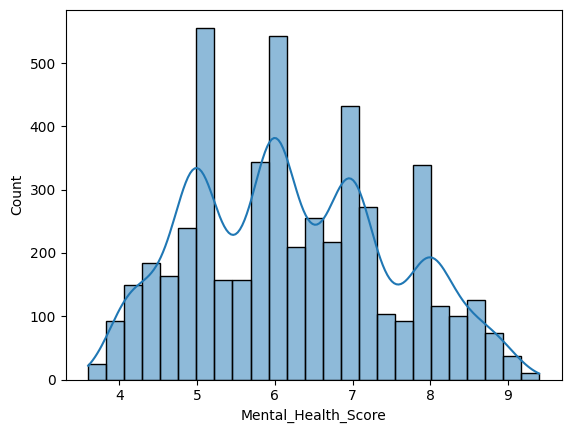

In [9]:
sns.histplot(df['Mental_Health_Score'],kde = True) # KDE----> Kernal Density Estimator


##3.2 - Correlation heatmap

* Which numeric features actually move together with the target?

<Axes: >

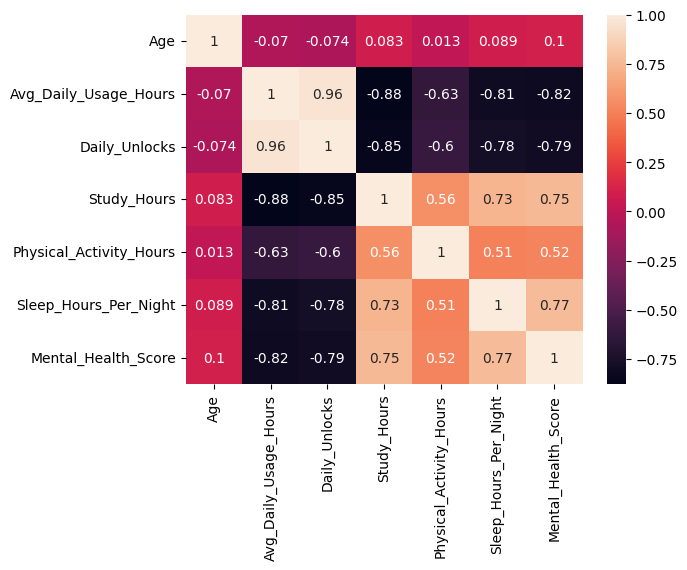

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot = True)

## 4.3 - Stress Level vs Mental Health Score

* Does higher stress genuinely come with a lower score?

In [11]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [12]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

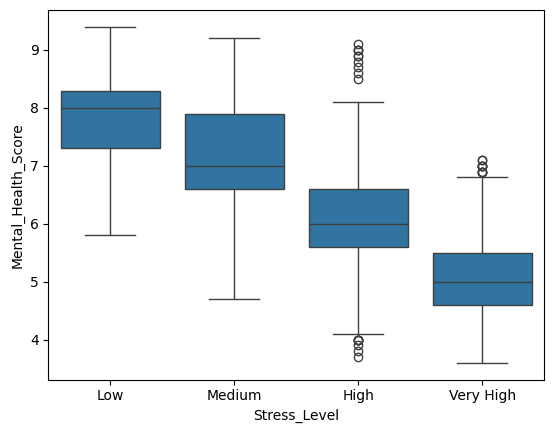

In [13]:
order = ['Low', 'Medium','High','Very High']
sns.boxplot(x='Stress_Level' , y = 'Mental_Health_Score', data = df,order = order)

##3.4 Daily Usage Hours vs Mental Health Score

* Does more time on social media relate to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

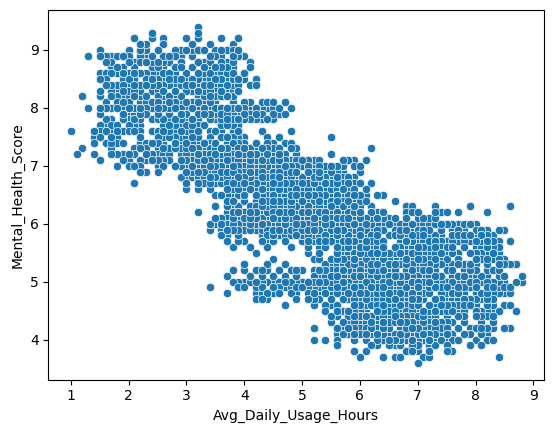

In [14]:
sns.scatterplot(x = "Avg_Daily_Usage_Hours", y = 'Mental_Health_Score', data = df )

* This plot tells me that there is negative correlation, why Negative correlation?
* ANS : lets observe one section i.e so if the avg_daily usage hours is 2 hrs, so the mental health score is between 8 and 9, whereas avg_dialy usage hours is 8 and 9 mental health score is low like 4 , so if avg _ daily usage hours is increased then mental health score is decreased , which is negative correlation.  

##3.5 - Sleep Hours vs Mental Health Score

* Sleep is one of the most commonly cited mental health factors - does the data back that up?

In [15]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

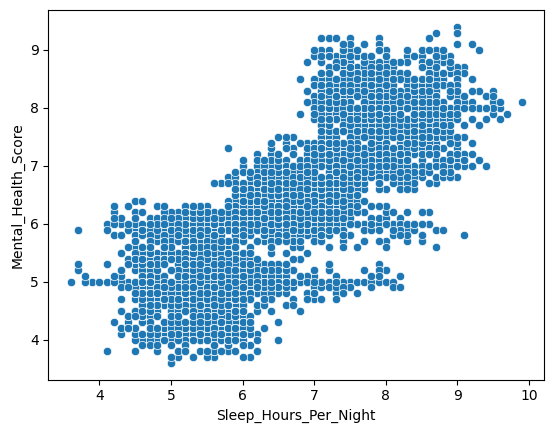

In [16]:
sns.scatterplot(x = 'Sleep_Hours_Per_Night', y = 'Mental_Health_Score', data = df)

* This graph tells me about positive correlation.

## 3.6 - Most Used Platform (Count)

* A quick look at which platforms are most common in our dataset

In [17]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [18]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


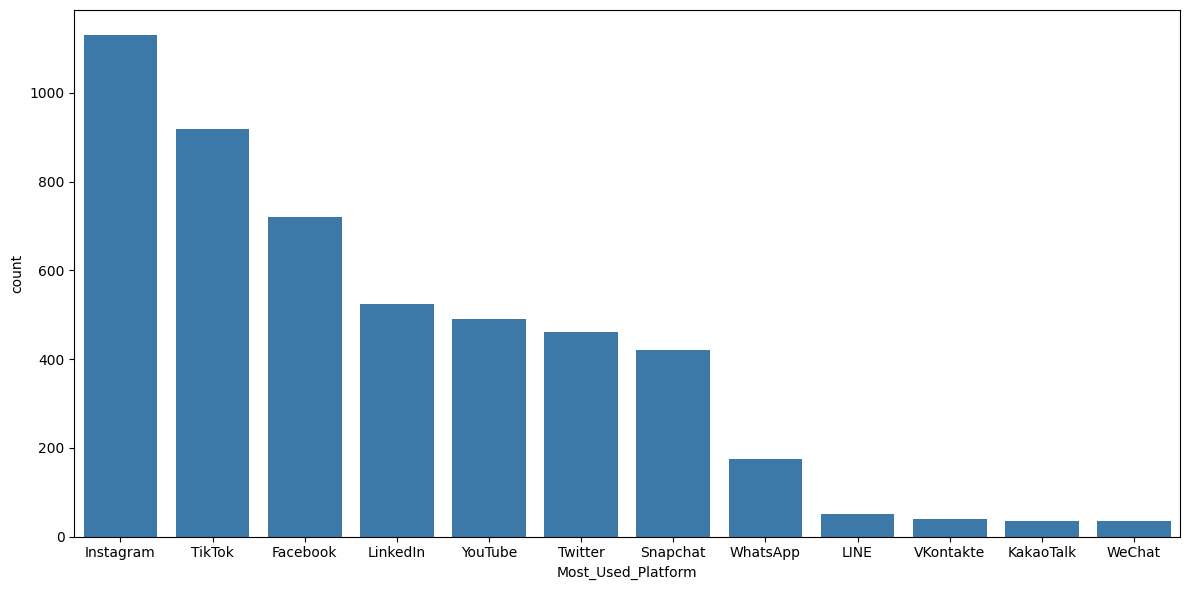

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(x = df['Most_Used_Platform'], order = df['Most_Used_Platform'].value_counts().index, color = '#2b7bba')

#plt.xticks(rotation = 45, ha = 'right')

plt.tight_layout()

plt.show()

#Checking Outliners

In [20]:
num_features = df.select_dtypes(include = 'number') # int64 or float64

Q1  = num_features.quantile(0.25)
Q3  = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())


Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


#4.Data Cleaning

* Two real issues to fix here- everything else in this dataset is already clean, so we don't manufacture steps that aren't needed

In [21]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [22]:
#1. to drop duplicates
df = df.drop_duplicates()

#2.converting negative or unrealistic value to realistic value---> use clip()
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower = 0)

In [23]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


#5.Skewness

In [24]:
num_cols = df.select_dtypes(include = 'number')
num_cols.skew()

# near to 0 -> Centralized (0.01,0.002)
# negative -> Left Skewed (-1.56)
# positive (greater than 0) -> Right Skewed(1.256)

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [25]:
# To correct the skewness we make use of log transformation

#6.Feature Engineering

In [26]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [27]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [28]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [29]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


#7.Encoding Strategy

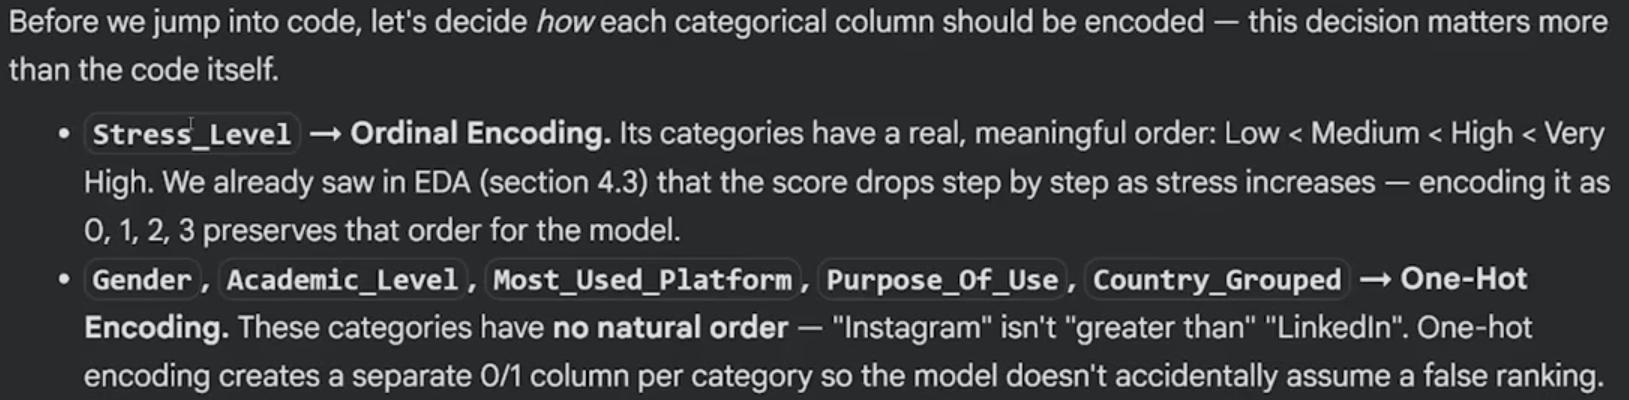

#8.Train-Test Split

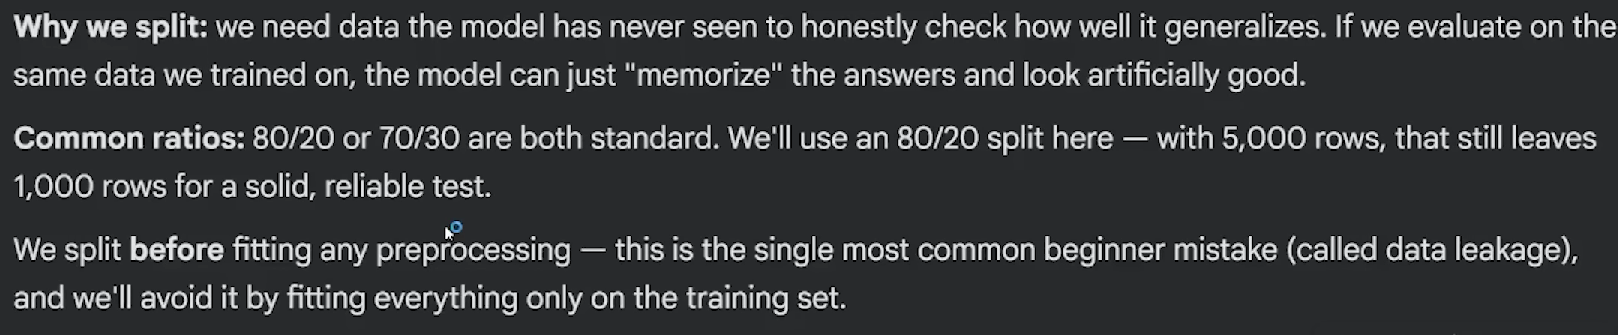

In [30]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_country'],
      dtype='object')

In [31]:
from sklearn.model_selection import train_test_split


skewed_col = ['Study_Hours']
other_numeric_cols = ['Age','Avg_Daily_Usage_Hours', 'Daily_Unlocks','Physical_Activity_Hours','Sleep_Hours_Per_Night']
ordinal_col = ['Stress_Level']
normal_col = ['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Grouped_country']

feature_col = skewed_col + other_numeric_cols + ordinal_col + normal_col

X = df[feature_col]
y = df['Mental_Health_Score']


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.30, random_state = 42)

#9.Preprocessing using ColumnTransform

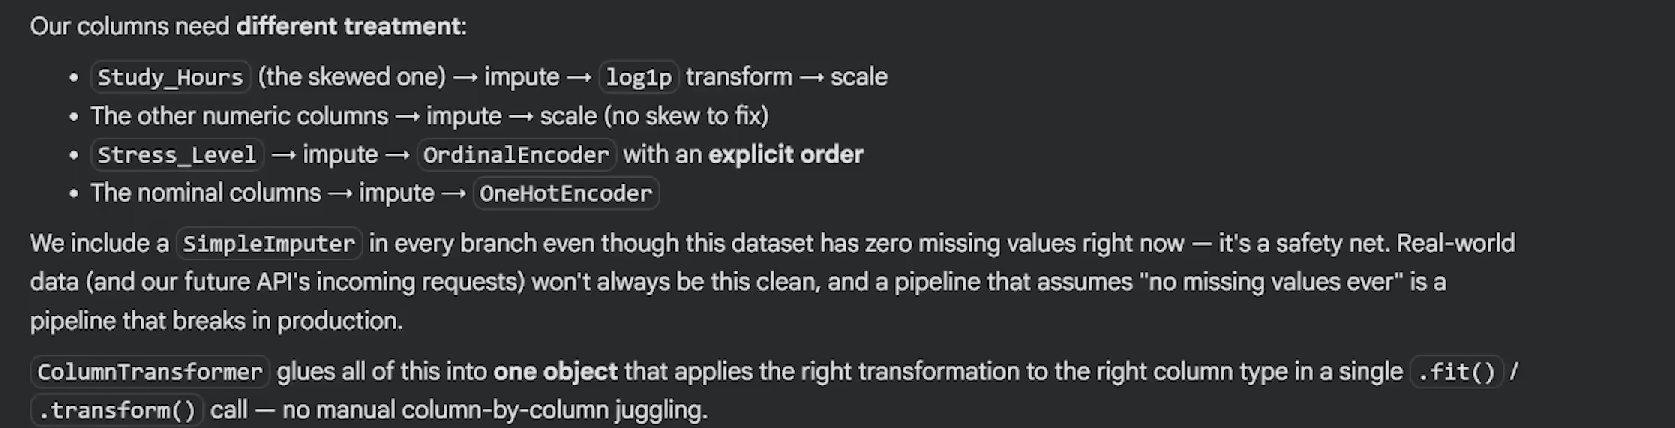

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer


#1.  Skewed features
skew_pipeline = Pipeline(steps =[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps = [
    ('scale',StandardScaler())
])

#3. Ordinal
ordinal_pipeline = Pipeline(steps = [
    ('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

#4.Nominal Features
nominal_pipeline = Pipeline(steps= [
    ('encode', OneHotEncoder(handle_unknown ='ignore'))
])


preprocessor = ColumnTransformer(transformers = [
    ("Skewed_pipeline",skew_pipeline, skewed_col),
    ("Plain_Numeric_Pipeline",plain_numeric_pipeline,other_numeric_cols),
    ("Ordinal_Pipeline",ordinal_pipeline,ordinal_col),
    ("Nominal_Pipeline", nominal_pipeline,normal_col)
])


#10.Build a Pipeline

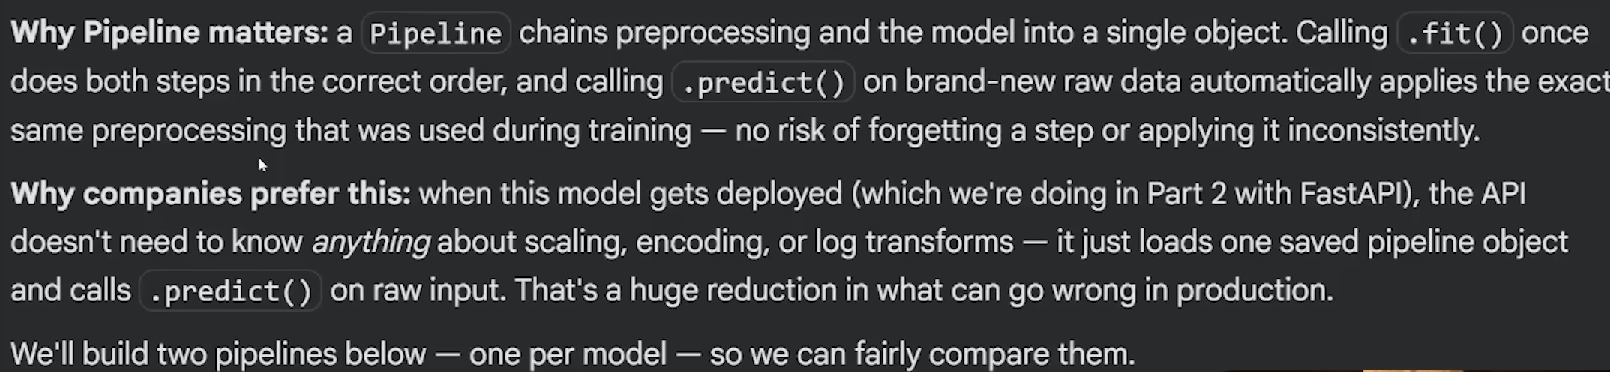

#11.Model Building

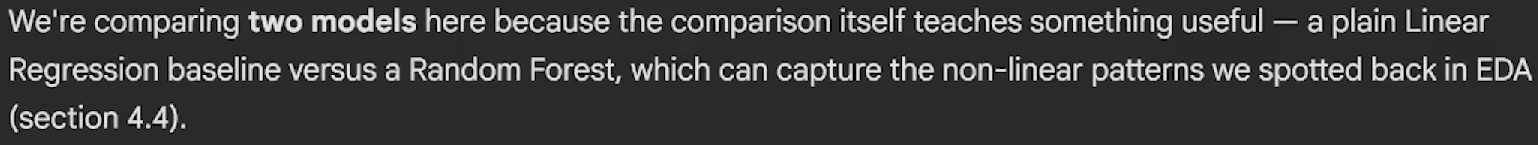

##11.1.**Baseline**:Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
lr_pipeline = Pipeline(steps = [
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)
lr_r2_test = r2_score(y_test,lr_preds)
lr_r2_train = r2_score(y_train,lr_preds_train)
lr_mae = mean_absolute_error(y_test, lr_preds)
print(f"Accuracy of Training:{lr_r2_test}")
print(f"Accuracy of Testing:{lr_r2_train}")
print(f"Mean Absolute Error{lr_mae}")

Accuracy of Training:0.7397944617433021
Accuracy of Testing:0.7236771199387538
Mean Absolute Error0.5361775634720181


##11.2RandomForest

In [34]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random forest',RandomForestRegressor(random_state = 42))
])

rf_pipeline.fit(X_train,y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test,rf_preds)
rf_r2_training = r2_score (y_train, rf_preds_training)
rf_mae = mean_absolute_error(y_test,rf_preds)

print(f"Accuracy of Training:{rf_r2_training}")
print(f"Accuracy of Testing:{rf_r2_testing}")
print(f"Mae:{rf_mae}")

Accuracy of Training:0.9808287942404612
Accuracy of Testing:0.8775888638668996
Mae:0.34722113333333343


##11.3.Hyperparameter Tuning the random Forest


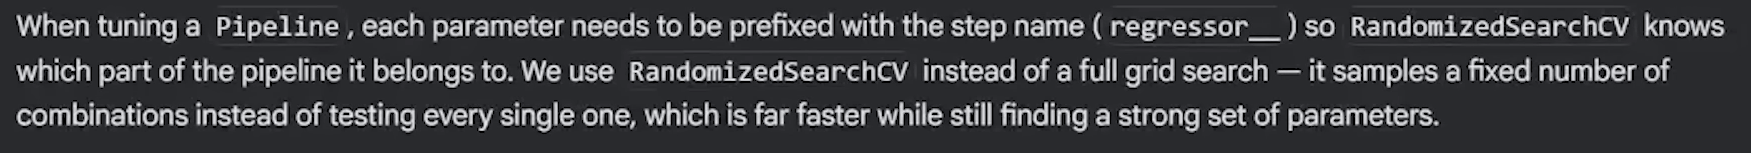

In [36]:
from sklearn.model_selection import RandomizedSearchCV


param_grid ={
    'random forest__n_estimators' : [100,200,300],
    'random forest__max_depth'    :[5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf' :[1,2,4]
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_grid,
    n_iter = 15,
    cv = 5,
    scoring = 'r2',
    random_state = 42,
    n_jobs = -1 # procssor free , to work with hyperparameter tuning
)
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric_Pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unl...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [37]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [43]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning:{r2_score(y_test,rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning:{mean_absolute_error(y_test,rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning:0.8650140569761653
MAE Score for random forest after hyperparameter tuning:0.3689015766630922


#12.Model Evaluation

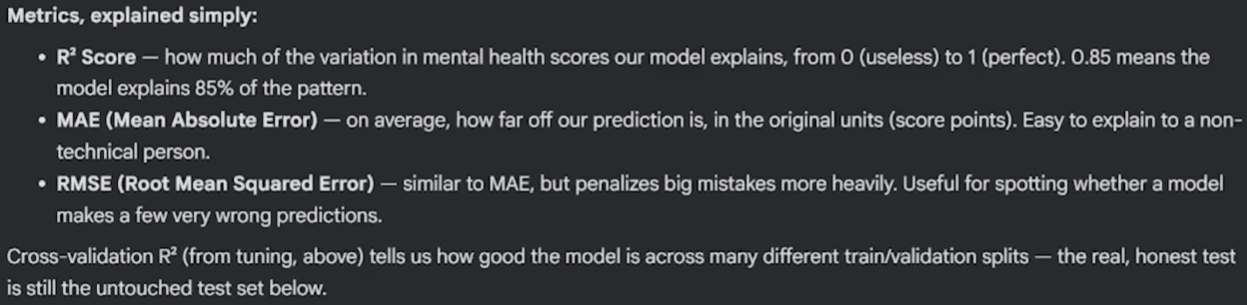

In [64]:
from sklearn.metrics import mean_squared_error

lr_mse = np.sqrt(mean_squared_error(y_test, lr_preds))

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))




rf_tunned_preds = random_search.best_estimator_.predict(X_test)
rf_tunned_rmse =np.sqrt(mean_squared_error(y_test, rf_tunned_preds))
rf_tunned_training_preds=random_search.best_estimator_.predict(X_train)
r2_tunned_training = r2_score(y_train, rf_tunned_training_preds)
rf_tunned_mae = mean_absolute_error(y_test, rf_tunned_preds)
rf_tunned_r2 = r2_score(y_test, rf_tunned_preds)


results = pd.DataFrame({
    'model' : ['Linear Regression', 'Random Forest', 'Random Forest Tunned'],
    'RMSE' : [lr_mse, rf_rmse, rf_tunned_rmse],
    'R2' : [lr_r2_test, rf_r2_testing,rf_tunned_r2],
    'Training R2' : [lr_r2_train, rf_r2_training,r2_tunned_training],
    'MAE' : [lr_mae,rf_mae,rf_tunned_mae]
})

print(results)


                  model      RMSE        R2  Training R2       MAE
0     Linear Regression  0.676032  0.739794     0.723677  0.536178
1         Random Forest  0.463681  0.877589     0.980829  0.347221
2  Random Forest Tunned  0.486915  0.865014     0.954703  0.368902


#13.Save Model

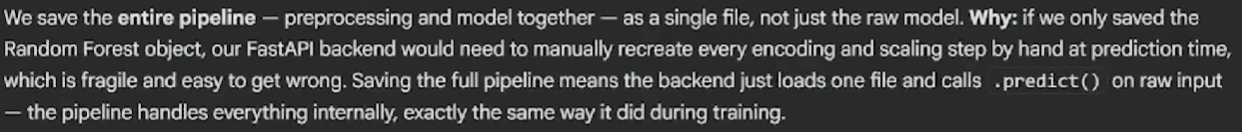

In [65]:
import joblib

joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

#Next Steps (Part 2 ):